# Wind Field Models

The `winds` module provides per-segment wind correction for flight plans.
Instead of assuming still air (or a single constant wind vector), hyplan
can query gridded wind fields that vary by location, altitude, and time.

Available wind sources:

| Source | Class | Use case | Credentials |
|--------|-------|----------|-------------|
| Still air | `StillAirField` | No-wind baseline | None |
| Constant | `ConstantWindField` | Simple uniform wind | None |
| MERRA-2 | `MERRA2WindField` | Historical planning | Earthdata |
| GFS | `GFSWindField` | Operational forecast (1-16 days) | None |
| GEOS-FP | `GMAOWindField` | Near-real-time analysis | None |

We cover:

1. Still air and constant wind fields
2. Comparing flight plans with and without wind
3. Wind direction and speed sensitivity
4. MERRA-2 reanalysis winds (historical)
5. GFS forecast winds (operational)
6. GMAO GEOS-FP winds (near-real-time)
7. Using the `wind_field_from_plan` factory
8. Trochoidal Dubins paths under wind

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

import datetime
import numpy as np
import matplotlib.pyplot as plt

from hyplan import (
    FlightLine,
    DynamicAviation_B200,
    Airport, initialize_data,
    compute_flight_plan, plot_flight_plan, plot_altitude_trajectory,
    ureg,
    StillAirField, ConstantWindField,
    wind_field_from_plan,
)

## 1. Setup: Flight Lines and Aircraft

We set up a simple mission with three east–west flight lines near Santa
Barbara at FL200 (20,000 ft). The B200 cruises at ~250 kt TAS at this
altitude, so wind effects on timing will be significant.

In [2]:
initialize_data(countries=["US"])

aircraft = DynamicAviation_B200()
departure = Airport("KSBA")

# Three east-west flight lines
flight_lines = []
for i, lat in enumerate([34.40, 34.35, 34.30]):
    az = 90.0 if i % 2 == 0 else 270.0  # alternating direction
    fl = FlightLine.center_length_azimuth(
        lat=lat, lon=-119.8,
        length=ureg.Quantity(80, "km"),
        az=az,
        altitude_msl=ureg.Quantity(20000, "feet"),
        site_name=f"Coastal_L{i+1:02d}",
    )
    flight_lines.append(fl)

print(f"Aircraft: {type(aircraft).__name__}")
print(f"Departure: {departure.name} ({departure.icao_code})")
print(f"\n{len(flight_lines)} flight lines (alternating E/W):")
for fl in flight_lines:
    print(f"  {fl.site_name}: {fl.length.to(ureg.km):.1f}, az={fl.az12:.0f}")

Aircraft: DynamicAviation_B200
Departure: Santa Barbara Municipal Airport (KSBA)

3 flight lines (alternating E/W):
  Coastal_L01: 80.0 kilometer, az=90 degree
  Coastal_L02: 80.0 kilometer, az=270 degree
  Coastal_L03: 80.0 kilometer, az=90 degree


## 2. Still Air and Constant Wind

`StillAirField` always returns zero wind — it is equivalent to omitting
the `wind_source` parameter entirely. `ConstantWindField` wraps a single
speed and direction into U/V components using meteorological convention
(direction is where the wind blows *from*).

In [3]:
still = StillAirField()
u, v = still.wind_at(34.0, -119.0, 20000 * ureg.feet, datetime.datetime.now())
print(f"Still air:  U={u.m_as('knot'):.1f} kt, V={v.m_as('knot'):.1f} kt")

# 40 kt wind from the west (blows eastward)
westerly = ConstantWindField(wind_speed=40 * ureg.knot, wind_from_deg=270.0)
u, v = westerly.wind_at(34.0, -119.0, 20000 * ureg.feet, datetime.datetime.now())
print(f"40 kt from west:  U={u.m_as('knot'):+.1f} kt, V={v.m_as('knot'):+.1f} kt")

# 30 kt wind from the northwest
nw_wind = ConstantWindField(wind_speed=30 * ureg.knot, wind_from_deg=315.0)
u, v = nw_wind.wind_at(34.0, -119.0, 20000 * ureg.feet, datetime.datetime.now())
print(f"30 kt from NW:    U={u.m_as('knot'):+.1f} kt, V={v.m_as('knot'):+.1f} kt")

Still air:  U=0.0 kt, V=0.0 kt
40 kt from west:  U=+40.0 kt, V=+0.0 kt
30 kt from NW:    U=+21.2 kt, V=-21.2 kt


## 3. Comparing Flight Plans With and Without Wind

A 40 kt westerly wind is a headwind on eastbound legs and a tailwind
on westbound legs. Wind affects both the **timing** and the **geometry**
of Dubins transit paths (turning arcs become trochoids). Flight line
segments use a simple headwind/tailwind correction along the line
bearing, while transit, departure, and return legs use the full
wind-aware 3D Dubins solver.

In [4]:
plan_still = compute_flight_plan(
    aircraft=aircraft,
    flight_sequence=flight_lines,
    takeoff_airport=departure,
    return_airport=departure,
)

plan_wind = compute_flight_plan(
    aircraft=aircraft,
    flight_sequence=flight_lines,
    takeoff_airport=departure,
    return_airport=departure,
    wind_source=westerly,
)

# Side-by-side comparison
cols = ["segment_type", "segment_name", "time_to_segment"]
comparison = plan_still[cols].copy()
comparison.columns = ["type", "segment", "still_air_min"]
comparison["with_wind_min"] = plan_wind["time_to_segment"].values
comparison["delta_min"] = comparison["with_wind_min"] - comparison["still_air_min"]

print(comparison.to_string(index=False, float_format="%.2f"))
print(f"\nTotal still air:  {comparison['still_air_min'].sum():.1f} min")
print(f"Total with wind:  {comparison['with_wind_min'].sum():.1f} min")
print(f"Net difference:   {comparison['delta_min'].sum():+.1f} min")

       type                    segment  still_air_min  with_wind_min  delta_min
    takeoff                  Departure          10.06          10.07       0.01
flight_line                Coastal_L01          13.29          11.26      -2.03
    transit Coastal_L01 to Coastal_L02           2.13           1.81      -0.32
flight_line                Coastal_L02          13.29          16.21       2.92
    transit Coastal_L02 to Coastal_L03           2.13           2.59       0.46
flight_line                Coastal_L03          13.29          11.26      -2.03
    descent                     Return          13.39          13.40       0.01

Total still air:  67.6 min
Total with wind:  66.6 min
Net difference:   -1.0 min


## 4. Wind Direction Sensitivity

How does a 40 kt wind from different directions affect total mission
time? We sweep wind direction from 0° (north) through 360° and plot
the resulting flight time.

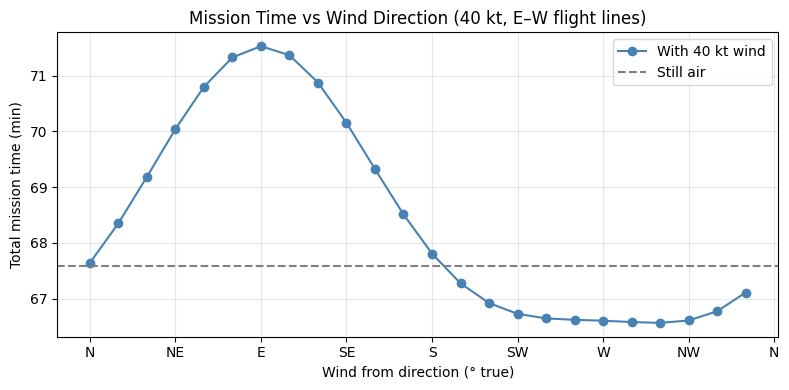

In [5]:
directions = np.arange(0, 360, 15)
times = []
ws = 40 * ureg.knot

for d in directions:
    wf = ConstantWindField(wind_speed=ws, wind_from_deg=float(d))
    plan = compute_flight_plan(
        aircraft=aircraft,
        flight_sequence=flight_lines,
        takeoff_airport=departure,
        return_airport=departure,
        wind_source=wf,
    )
    times.append(plan["time_to_segment"].sum())

baseline = compute_flight_plan(
    aircraft=aircraft,
    flight_sequence=flight_lines,
    takeoff_airport=departure,
    return_airport=departure,
)["time_to_segment"].sum()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(directions, times, "o-", color="steelblue", label="With 40 kt wind")
ax.axhline(baseline, color="gray", linestyle="--", label="Still air")
ax.set_xlabel("Wind from direction (\u00b0 true)")
ax.set_ylabel("Total mission time (min)")
ax.set_title("Mission Time vs Wind Direction (40 kt, E\u2013W flight lines)")
ax.set_xticks(np.arange(0, 361, 45))
ax.set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW", "N"])
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# The worst case is always a headwind along the dominant flight axis.
# For E-W lines, wind from the east or west has the largest effect.
# Crosswinds (N/S) have minimal impact on timing.

## 5. Wind Speed Sensitivity

How does increasing wind speed affect mission time? With alternating
east/west flight lines, *any* wind increases total mission time because
headwind penalties always exceed tailwind savings. We compare wind from
the east vs west at various speeds.

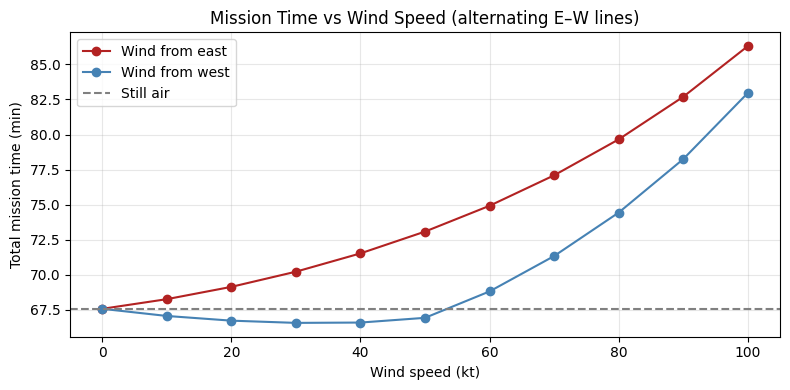

Still air baseline: 67.6 min
At 100 kt from east: 86.3 min (+28%)
At 100 kt from west: 83.0 min (+23%)

Both directions increase total time — headwind penalty
always exceeds tailwind savings on reciprocal legs.


In [6]:
speeds_kt = np.arange(0, 101, 10)
times_from_east = []
times_from_west = []

for s in speeds_kt:
    for direction, result_list in [(90.0, times_from_east), (270.0, times_from_west)]:
        wf = ConstantWindField(wind_speed=s * ureg.knot, wind_from_deg=direction)
        plan = compute_flight_plan(
            aircraft=aircraft,
            flight_sequence=flight_lines,
            takeoff_airport=departure,
            return_airport=departure,
            wind_source=wf,
        )
        result_list.append(plan["time_to_segment"].sum())

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(speeds_kt, times_from_east, "o-", color="firebrick", label="Wind from east")
ax.plot(speeds_kt, times_from_west, "o-", color="steelblue", label="Wind from west")
ax.axhline(times_from_east[0], color="gray", linestyle="--", label="Still air")
ax.set_xlabel("Wind speed (kt)")
ax.set_ylabel("Total mission time (min)")
ax.set_title("Mission Time vs Wind Speed (alternating E\u2013W lines)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

baseline = times_from_east[0]
print(f"Still air baseline: {baseline:.1f} min")
print(f"At 100 kt from east: {times_from_east[-1]:.1f} min ({(times_from_east[-1]/baseline-1)*100:+.0f}%)")
print(f"At 100 kt from west: {times_from_west[-1]:.1f} min ({(times_from_west[-1]/baseline-1)*100:+.0f}%)")
print(f"\nBoth directions increase total time \u2014 headwind penalty")
print(f"always exceeds tailwind savings on reciprocal legs.")

## 6. MERRA-2 Reanalysis Winds (Historical)

For planning against historical data (“what were winds on this date
last year?”), use `wind_field_from_plan("merra2", ...)`. This fetches
3-hourly U/V winds on 42 pressure levels at 0.5° resolution via
OPeNDAP from NASA GES DISC.

**Prerequisites:** Set the `EARTHDATA_TOKEN` environment variable or
add your NASA Earthdata credentials to `~/.netrc`. Register at
https://urs.earthdata.nasa.gov if needed.

The `wind_field_from_plan` factory computes the geographic and temporal
bounding box from your flight sequence and fetches only the necessary
sub-region (server-side subsetting via OPeNDAP).

In [7]:
import os

# Only run this cell if Earthdata credentials are available
has_earthdata = (
    os.environ.get("EARTHDATA_TOKEN")
    or os.path.exists(os.path.expanduser("~/.netrc"))
)

if has_earthdata:
    takeoff_time = datetime.datetime(2024, 6, 15, 14, 0, tzinfo=datetime.timezone.utc)

    wf_merra2 = wind_field_from_plan(
        "merra2",
        flight_lines,
        takeoff_time,
        takeoff_airport=departure,
        return_airport=departure,
    )

    # Query the wind at a representative point
    u, v = wf_merra2.wind_at(
        34.4, -119.8, 20000 * ureg.feet, takeoff_time,
    )
    ws = np.sqrt(u.m_as("knot")**2 + v.m_as("knot")**2)
    wdir = (270 - np.degrees(np.arctan2(v.m_as("m/s"), u.m_as("m/s")))) % 360
    print(f"MERRA-2 wind at FL200, 2024-06-15 14:00 UTC:")
    print(f"  U = {u.m_as('knot'):+.1f} kt, V = {v.m_as('knot'):+.1f} kt")
    print(f"  Speed = {ws:.0f} kt from {wdir:.0f}\u00b0")
else:
    print("Earthdata credentials not found. Skipping MERRA-2 demo.")
    print("Set EARTHDATA_TOKEN or add credentials to ~/.netrc.")

/Users/rpavlick/.pyenv/versions/3.11.11/lib/python3.11/site-packages/pydap/handlers/dap.py:184: UserWarning: PyDAP was unable to determine the DAP protocol defaulting to DAP2. DAP2 is consider legacy and may result in slower responses. 
Consider replacing `http` in your `url` with either `dap2` or `dap4` to specify the DAP protocol (e.g. `dap2://<data_url>` or `dap4://<data_url>`).  For more 
information, go to https://www.opendap.org/faq-page.
  warnings.warn(
/Users/rpavlick/.pyenv/versions/3.11.11/lib/python3.11/site-packages/pydap/handlers/dap.py:184: UserWarning: PyDAP was unable to determine the DAP protocol defaulting to DAP2. DAP2 is consider legacy and may result in slower responses. 
Consider replacing `http` in your `url` with either `dap2` or `dap4` to specify the DAP protocol (e.g. `dap2://<data_url>` or `dap4://<data_url>`).  For more 
information, go to https://www.opendap.org/faq-page.
  warnings.warn(


MERRA-2 wind at FL200, 2024-06-15 14:00 UTC:
  U = +31.5 kt, V = +0.3 kt
  Speed = 32 kt from 269°


### Flight Plan with MERRA-2 Winds

Compare the flight plan computed with MERRA-2 reanalysis winds against
the still-air baseline.

In [8]:
if has_earthdata:
    plan_merra2 = compute_flight_plan(
        aircraft=aircraft,
        flight_sequence=flight_lines,
        takeoff_airport=departure,
        return_airport=departure,
        wind_source=wf_merra2,
        takeoff_time=takeoff_time,
    )

    # Compare
    cols = ["segment_type", "segment_name", "time_to_segment"]
    comp = plan_still[cols].copy()
    comp.columns = ["type", "segment", "still_air"]
    comp["merra2"] = plan_merra2["time_to_segment"].values
    comp["delta"] = comp["merra2"] - comp["still_air"]

    print(comp.to_string(index=False, float_format="%.2f"))
    print(f"\nTotal still air: {comp['still_air'].sum():.1f} min")
    print(f"Total MERRA-2:   {comp['merra2'].sum():.1f} min")
    print(f"Difference:      {comp['delta'].sum():+.1f} min")
else:
    print("Skipped (no Earthdata credentials).")

       type                    segment  still_air  merra2  delta
    takeoff                  Departure      10.06   10.07   0.00
flight_line                Coastal_L01      13.29   11.60  -1.69
    transit Coastal_L01 to Coastal_L02       2.13    1.88  -0.25
flight_line                Coastal_L02      13.29   15.35   2.06
    transit Coastal_L02 to Coastal_L03       2.13    2.48   0.35
flight_line                Coastal_L03      13.29   11.65  -1.64
    descent                     Return      13.39   13.39   0.00

Total still air: 67.6 min
Total MERRA-2:   66.4 min
Difference:      -1.2 min


## 7. GFS Forecast Winds (Operational)

NOAA's Global Forecast System (GFS) provides 0.25° resolution wind
forecasts out to 16 days, updated every 6 hours. No credentials
are needed.

`GFSWindField` uses the NOMADS GRIB filter for server-side subsetting —
only the requested variables, pressure levels, and geographic region
are downloaded (~10 KB vs ~500 MB for a full file).

`wind_field_from_plan` automatically selects the most recent GFS cycle
and the forecast hour closest to your mission time.

In [9]:
# Use a takeoff time a few hours from now (within GFS forecast range)
gfs_takeoff = datetime.datetime.now(tz=datetime.timezone.utc) + datetime.timedelta(hours=6)

try:
    wf_gfs = wind_field_from_plan(
        "gfs",
        flight_lines,
        gfs_takeoff,
        takeoff_airport=departure,
        return_airport=departure,
    )

    # Query the wind at a representative point
    u, v = wf_gfs.wind_at(34.4, -119.8, 20000 * ureg.feet, gfs_takeoff)
    ws = np.sqrt(u.m_as('knot')**2 + v.m_as('knot')**2)
    wdir = (270 - np.degrees(np.arctan2(v.m_as('m/s'), u.m_as('m/s')))) % 360
    print(f"GFS wind at FL200, {gfs_takeoff:%Y-%m-%d %H:%M} UTC:")
    print(f"  U = {u.m_as('knot'):+.1f} kt, V = {v.m_as('knot'):+.1f} kt")
    print(f"  Speed = {ws:.0f} kt from {wdir:.0f}\u00b0")
    has_gfs = True
except Exception as e:
    print(f"GFS unavailable: {e}")
    has_gfs = False

GFS wind at FL200, 2026-04-11 10:09 UTC:
  U = +32.3 kt, V = +2.7 kt
  Speed = 32 kt from 265°


### Flight Plan with GFS Winds

Compare the GFS-corrected flight plan against the still-air baseline.

In [10]:
if has_gfs:
    plan_gfs = compute_flight_plan(
        aircraft=aircraft,
        flight_sequence=flight_lines,
        takeoff_airport=departure,
        return_airport=departure,
        wind_source=wf_gfs,
        takeoff_time=gfs_takeoff,
    )

    cols = ["segment_type", "segment_name", "time_to_segment"]
    comp = plan_still[cols].copy()
    comp.columns = ["type", "segment", "still_air"]
    comp["gfs"] = plan_gfs["time_to_segment"].values
    comp["delta"] = comp["gfs"] - comp["still_air"]

    print(comp.to_string(index=False, float_format="%.2f"))
    print(f"\nTotal still air: {comp['still_air'].sum():.1f} min")
    print(f"Total GFS:       {comp['gfs'].sum():.1f} min")
    print(f"Difference:      {comp['delta'].sum():+.1f} min")
else:
    print("Skipped (GFS endpoint unavailable).")

       type                    segment  still_air   gfs  delta
    takeoff                  Departure      10.06 10.07   0.00
flight_line                Coastal_L01      13.29 11.67  -1.62
    transit Coastal_L01 to Coastal_L02       2.13  1.86  -0.27
flight_line                Coastal_L02      13.29 15.67   2.38
    transit Coastal_L02 to Coastal_L03       2.13  2.48   0.35
flight_line                Coastal_L03      13.29 11.67  -1.62
    descent                     Return      13.39 13.39   0.00

Total still air: 67.6 min
Total GFS:       66.8 min
Difference:      -0.8 min


## 8. GMAO GEOS-FP Winds (Near-Real-Time)

NASA GMAO provides GEOS-FP analysis fields at 0.25° resolution,
typically covering the last ~30 days. No credentials required.

> **Note:** The GMAO Fluid OPeNDAP server may be intermittently
> unavailable. This demo is wrapped in a try/except.


In [11]:
gmao_takeoff = datetime.datetime.now(tz=datetime.timezone.utc)

try:
    wf_gmao = wind_field_from_plan(
        "gmao",
        flight_lines,
        gmao_takeoff,
        takeoff_airport=departure,
        return_airport=departure,
    )

    u, v = wf_gmao.wind_at(34.4, -119.8, 20000 * ureg.feet, gmao_takeoff)
    ws = np.sqrt(u.m_as('knot')**2 + v.m_as('knot')**2)
    wdir = (270 - np.degrees(np.arctan2(v.m_as('m/s'), u.m_as('m/s')))) % 360
    print(f"GEOS-FP wind at FL200, {gmao_takeoff:%Y-%m-%d %H:%M} UTC:")
    print(f"  U = {u.m_as('knot'):+.1f} kt, V = {v.m_as('knot'):+.1f} kt")
    print(f"  Speed = {ws:.0f} kt from {wdir:.0f}°")
    has_gmao = True
except Exception as e:
    print(f"GMAO unavailable: {e}")
    has_gmao = False

GEOS-FP wind at FL200, 2026-04-11 04:09 UTC:
  U = +20.2 kt, V = +22.2 kt
  Speed = 30 kt from 222°


### Flight Plan with GEOS-FP Winds


In [12]:
if has_gmao:
    plan_gmao = compute_flight_plan(
        aircraft=aircraft,
        flight_sequence=flight_lines,
        takeoff_airport=departure,
        return_airport=departure,
        wind_source=wf_gmao,
        takeoff_time=gmao_takeoff,
    )

    cols = ["segment_type", "segment_name", "time_to_segment"]
    comp = plan_still[cols].copy()
    comp.columns = ["type", "segment", "still_air"]
    comp["gmao"] = plan_gmao["time_to_segment"].values
    comp["delta"] = comp["gmao"] - comp["still_air"]

    print(comp.to_string(index=False, float_format="%.2f"))
    print(f"\nTotal still air: {comp['still_air'].sum():.1f} min")
    print(f"Total GEOS-FP:   {comp['gmao'].sum():.1f} min")
    print(f"Difference:      {comp['delta'].sum():+.1f} min")
else:
    print("Skipped (GMAO endpoint unavailable).")

       type                    segment  still_air  gmao  delta
    takeoff                  Departure      10.06 10.07   0.00
flight_line                Coastal_L01      13.29 12.07  -1.22
    transit Coastal_L01 to Coastal_L02       2.13  2.02  -0.12
flight_line                Coastal_L02      13.29 14.51   1.22
    transit Coastal_L02 to Coastal_L03       2.13  2.43   0.30
flight_line                Coastal_L03      13.29 12.04  -1.25
    descent                     Return      13.39 13.39   0.00

Total still air: 67.6 min
Total GEOS-FP:   66.5 min
Difference:      -1.1 min


## 9. Using the Factory Function

The `wind_field_from_plan` factory is the recommended way to create wind
fields. It computes the spatial/temporal bounding box from your flight
sequence and only downloads the data you need.

| Source | Description |
|--------|-------------|
| `"still_air"` | Zero wind everywhere |
| `"merra2"` | NASA MERRA-2 reanalysis (historical) |
| `"gfs"` | NOAA GFS forecast (operational, 1-16 days) |
| `"gmao"` | NASA GEOS-FP near-real-time analysis |

In [13]:
# Still air via factory
wf_still = wind_field_from_plan(
    "still_air",
    flight_lines,
    takeoff_time=datetime.datetime.now(tz=datetime.timezone.utc),
)
u, v = wf_still.wind_at(34.0, -119.0, 20000 * ureg.feet, datetime.datetime.now())
print(f"still_air: U={u.m_as('knot'):.0f}, V={v.m_as('knot'):.0f} kt")

# Constant wind is created directly (not via factory)
wf_const = ConstantWindField(wind_speed=25 * ureg.knot, wind_from_deg=180.0)
u, v = wf_const.wind_at(34.0, -119.0, 20000 * ureg.feet, datetime.datetime.now())
print(f"constant 25 kt from S: U={u.m_as('knot'):+.1f}, V={v.m_as('knot'):+.1f} kt")

# GFS and MERRA-2 require network access:
# wf_gfs = wind_field_from_plan("gfs", flight_lines, takeoff_time)
# wf_merra2 = wind_field_from_plan("merra2", flight_lines, takeoff_time)

still_air: U=0, V=0 kt
constant 25 kt from S: U=-0.0, V=+25.0 kt


## 10. Trochoidal Dubins Paths Under Wind

When `DubinsPath3D` receives a `wind` parameter, turning arcs in the
horizontal plane become **trochoids** instead of pure circles. A
trochoid is the curve traced by a point on a circle that is rolling
(or, equivalently, drifting with the wind). The solver finds the
time-optimal path in the air-relative frame and samples the ground
track with wind drift applied.

Below we build the Dubins transit paths between the same three
east–west flight lines used above, with and without a 60 kt westerly
wind. The still-air paths show clean circular arcs while the wind
paths show the characteristic trochoidal loops where the aircraft's
circular (air-frame) turns are distorted by wind drift.

In [33]:
import folium
from hyplan import DubinsPath3D

# Aircraft parameters for Dubins path construction
cruise_speed = aircraft.cruise_speed_at(20000 * ureg.feet)
bank_angle = 15.0
pitch_min, pitch_max = aircraft.pitch_limits(cruise_speed)

# 60 kt westerly wind (blows eastward): u_east > 0, v_north = 0
wind_speed_kt = 60
wind_u_mps = (wind_speed_kt * ureg.knot).m_as("m/s")
wind_vec = (wind_u_mps, 0.0)

print(f"Cruise TAS: {cruise_speed.to(ureg.knot):.0f}")
print(f"Bank angle: {bank_angle}°")
print(f"Wind: {wind_speed_kt} kt from west (u={wind_u_mps:.1f} m/s east)")

# Build transit Dubins paths between consecutive flight lines
transit_pairs = [
    (flight_lines[0].waypoint2, flight_lines[1].waypoint1, "L01 \u2192 L02"),
    (flight_lines[1].waypoint2, flight_lines[2].waypoint1, "L02 \u2192 L03"),
]

paths_still = []
paths_wind = []

for start_wp, end_wp, label in transit_pairs:
    path_no_wind = DubinsPath3D(
        start=start_wp, end=end_wp,
        speed=cruise_speed, bank_angle=bank_angle,
        pitch_min=pitch_min, pitch_max=pitch_max,
        step_size=100.0,
    )
    path_with_wind = DubinsPath3D(
        start=start_wp, end=end_wp,
        speed=cruise_speed, bank_angle=bank_angle,
        pitch_min=pitch_min, pitch_max=pitch_max,
        step_size=100.0,
        wind=wind_vec,
    )
    paths_still.append((label, path_no_wind))
    paths_wind.append((label, path_with_wind))
    print(f"\n{label}:")
    print(f"  Still air path: {path_no_wind.length.to(ureg.km):.1f}")
    print(f"  Wind path:      {path_with_wind.length.to(ureg.km):.1f}")

Cruise TAS: 222 knot
Bank angle: 15.0°
Wind: 60 kt from west (u=30.9 m/s east)

L01 → L02:
  Still air path: 29.2 kilometer
  Wind path:      26.3 kilometer

L02 → L03:
  Still air path: 29.2 kilometer
  Wind path:      26.6 kilometer


In [34]:
# Build folium map comparing still-air (circular) vs wind (trochoidal) paths
center_lat = np.mean([fl.lat1 for fl in flight_lines])
center_lon = np.mean([fl.lon1 for fl in flight_lines])

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=11,
    tiles="CartoDB positron",
)

# Flight lines (shared geometry)
for fl in flight_lines:
    coords = [(lat, lon) for lon, lat in fl.geometry.coords]
    folium.PolyLine(
        coords, color="steelblue", weight=4, opacity=0.9,
        tooltip=f"{fl.site_name} ({fl.az12:.0f})",
    ).add_to(m)
    # Endpoint markers
    for wp, end in [(fl.waypoint1, "start"), (fl.waypoint2, "end")]:
        folium.CircleMarker(
            [wp.latitude, wp.longitude], radius=4,
            color="steelblue", fill=True, fill_opacity=0.8,
        ).add_to(m)

# Still-air transit paths (circular arcs) -- dashed gray
for label, path in paths_still:
    coords = [(lat, lon) for lon, lat in path.geometry.coords]
    folium.PolyLine(
        coords, color="gray", weight=3, opacity=0.8,
        dash_array="6",
        tooltip=f"{label} (still air)",
    ).add_to(m)

# Wind transit paths (trochoidal arcs) -- solid red
for label, path in paths_wind:
    coords = [(lat, lon) for lon, lat in path.geometry.coords]
    folium.PolyLine(
        coords, color="crimson", weight=3, opacity=0.9,
        tooltip=f"{label} ({wind_speed_kt} kt westerly)",
    ).add_to(m)

# Wind arrow indicator (lower-left area of map)
arrow_lat, arrow_lon = center_lat - 0.07, center_lon - 0.35
folium.Marker(
    [arrow_lat, arrow_lon],
    icon=folium.DivIcon(html=(
        f'<div style="font-size:12px; white-space:nowrap; color:#333;">'
        f'<b>{wind_speed_kt} kt</b> &rarr; (from west)</div>'
    )),
).add_to(m)

# Legend
legend_html = """
<div style="position:fixed; bottom:30px; right:30px; z-index:1000;
     background:white; padding:10px 14px; border-radius:6px;
     border:1px solid #ccc; font-size:12px; line-height:1.6;">
  <b>Transit paths</b><br>
  <span style="color:gray;">&mdash; &mdash;</span> Still air (circular arcs)<br>
  <span style="color:crimson;">&mdash;&mdash;</span> 60 kt wind (trochoidal arcs)<br>
  <span style="color:steelblue;">&mdash;&mdash;</span> Flight lines
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

m

## Summary

| Class / Function | Purpose |
|-----------------|--------|
| `StillAirField()` | Zero wind baseline |
| `ConstantWindField(speed, direction)` | Uniform wind everywhere |
| `MERRA2WindField(...)` | Historical reanalysis via OPeNDAP |
| `GFSWindField(...)` | NOAA GFS operational forecast |
| `GMAOWindField(...)` | GEOS-FP near-real-time analysis |
| `wind_field_from_plan(source, seq, time)` | Auto-builds wind field for a mission |
| `compute_flight_plan(..., wind_source=wf)` | Flight plan with per-segment wind |

**Key points:**
- Wind direction follows meteorological convention (direction the wind blows *from*)
- U is eastward (positive = from west), V is northward (positive = from south)
- Headwind penalties always exceed tailwind savings
- At jet altitudes, 50–100 kt winds are common and can shift mission time by 15–30%
- `MERRA2WindField` requires NASA Earthdata credentials; GFS and GMAO do not